# Characterizing the vertical structure of oxygen in the ocean

Argovis provides an API that indexes and distributes numerous oceanographic datasets with detailed query parameters, enabling you to search and download only and exactly the data of interest.

This notebook guides users in exploring the vertical structure of oxygen in the ocean using ocean observations and gridded products (i.e. products that provide maps of oxygen at different depths, starting from sparse point measurements). While the focus is on oxygen, the same notebook can be used to visualize other fields.

## Learning goals
- Generate an average vertical profile of oxygen for a region in the North Atlantic and a region in the North Pacific Ocean using Argo oxygen data.
- Describe the features of the two profiles, noting similarities and differences.
- Discuss the reasons for the differences between the two profiles.
- Visualize a GO-SHIP / WOCE repeat hydrographic line in each basin and discuss differences and similarities between the two basins.

## Setup: register an API key

In order to allocate Argovis's limited computing resources fairly, users are encouraged to register and request a free API key. This works like a password that identifies your requests to Argovis.

1. Visit [https://argovis-keygen.colorado.edu/](https://argovis-keygen.colorado.edu/)
2. Fill out the form under **New Account Registration**
3. An API key will be emailed to you shortly

Treat your API key like a password — don't share it or leave it anywhere public. If you ever forget it or accidentally reveal it, visit the same website to change or deactivate your token.

Set `APIKEY` in the cell below before running anything else. The notebook may still work with `'guest'` but may return errors under heavy load.

## Setup: import libraries and functions

In [1]:
from argovisHelpers import helpers as avh
from argovisHelpers import analysis as ava
import matplotlib.pyplot as plt
import gsw, numpy
import xarray as xr
import cartopy.crs as ccrs
import numpy as np
import pandas as pd 
import matplotlib.dates as mdates
import warnings
from datetime import datetime
warnings.filterwarnings("ignore", category=RuntimeWarning)

APIKEY = 'guest'
APIROOT = 'https://argovis-api.colorado.edu/'


### Import helper functions
The functions below are used throughout the notebook. You do not need to edit them — they read plotting conventions (`DATASET_COLORS`, `DEPTH_YLIM`, etc.) from the configuration cell above.
- `traverse_query` Loop over all region × time × dataset combinations and call the Argovis API 
- `plot_maps` Scatter profile locations on a map 
- `compare_profiles` Plot individual or mean vertical profiles; to plot means, pre-average with `average_profiles_dict` and pass `mean_style=True` 
- `average_profiles_dict` Compute level-by-level mean profiles across a list of Profile objects, returned as a single-entry dict ready for `compare_profiles` 

In [2]:
from functions import traverse_query, plot_maps, compare_profiles, average_profiles_dict

## Setup: configuration

Define your regions, time periods, datasets, and plotting conventions here. **This is the main cell to edit** — all downstream cells read from these variables.

Key parameters:
- `regions`: list of bounding boxes or polygons to query
- `time_periods`: list of start/end date pairs
- `insitu` / `grids`: datasets and variables to retrieve
- `DEPTH_YLIM`: maximum pressure (dbar) shown on **all** depth-axis plots — change this one value to zoom in or out everywhere
- `DATASET_COLORS`: one color per dataset/product, used consistently across all profile plots

In [3]:
regions = [
    {"box": [[-50,45],[-40,50]]},
    {"box": [[-145.5,45.5],[-135.5,50.5]]}
]

time_periods = [
    {"startDate": "2018-01-01T00:00:00Z", "endDate": "2018-12-31T00:00:00Z"},
]

insitu = {
    "argo":      "temperature,1,salinity,1,doxy,1", 
    "cchdo":     "salinity,temperature,doxy",
}

grids = {
    "grids/rg09":            "rg09_temperature,rg09_salinity,oxygen",
    "grids/localGPintegral": "potential_temperature",
}

# Interpolation levels — defined once here; reused in the platform/WOCE section
interpolation_levels = avh.rg_levels()
# interpolation_levels = np.arange(10, 210, 10)

# ── Plotting conventions ───────────────────────────────────────────────────────
DATASET_COLORS = {
    'argo': 'red',
    'cchdo': 'green',
    'grids/glodap': 'yellow',
    'easyocean': 'darkblue',

}

# TIME_MARKERS, TIME_LINESTYLES, and REGION_MARKERS are lists sized for up to
# several time periods/regions. 
TIME_LINESTYLES = ['-', '--', ':', '-.']
TIME_MARKERS    = ['o', '^', 'p', 'D', 'v', '*']
REGION_MARKERS  = ['o', 'P', 'D', 'v', 'p', '*']   # 'P' = fat plus, very distinct from 'o'
REGION_MARKERSIZE = 6
REGION_MARKEREDGECOLOR = 'black'
REGION_MARKEREDGEWIDTH = 0.5

# GLODAP is a climatology, not a time period — give it a distinct linestyle
GLODAP_LINESTYLE = (0, (1, 1))   # densely dotted

# Maximum pressure/depth shown on ALL profile and section plots.
# Change this one value to zoom in or out on all depth axes at once.
# DEPTH_YLIM = 2000  # dbar
DEPTH_YLIM = None  # uncomment to plot full depth

salinity_key = {
    'argo':      'salinity',
    'cchdo':     'salinity',
    'easyocean': 'ctd_salinity',
}
temperature_key = {
    'argo':      'temperature',
    'cchdo':     'temperature',
    'easyocean': 'ctd_temperature',
}

# Region colors — used in Parts 1 & 2 to distinguish regions
REGION_COLORS = ['darkblue', 'orange', 'green', 'red', 'purple', 'brown']

# Dataset markers and linestyles — used in Parts 1 & 2
DATASET_MARKERS = {
    'argo':        'o',
    'cchdo':       'P',
    'grids/glodap': 'D',
}
DATASET_LINESTYLES = {
    'argo':        '-',
    'cchdo':       '--',
    'grids/glodap': (0, (1, 1)),   # dotted for climatology
}

# Section colors — used in Part 3 to distinguish WOCE lines
SECTION_COLORS = {
    'P16':     'red',
    'A16-A23': 'green',
}

# Part 1 — In-situ data
### Argo and CCHDO profiles

**Argo** is a global array of autonomous profiling floats measuring temperature, salinity, and (on BGC floats) oxygen down to 2000 m.  
**CCHDO** provides high-quality ship-based hydrographic data (GO-SHIP repeat lines), offering full-depth coverage but at lower spatial and temporal density than Argo.

The two datasets are queried together so they can be compared on the same axes.

### Step 1 — Query raw profiles from the Argovis API

The cell below loops over all region × time × dataset combinations and downloads the matching profiles.

Depending on the spatial extent and number of regions/time periods selected, this cell may take several minutes to complete.

In [4]:
insitu_raw = traverse_query(regions, time_periods, insitu, avh.queryProfile, APIKEY, APIROOT)


### Step 2 — Interpolate profiles onto common pressure levels

Raw profiles report data at irregular pressure levels that differ between floats and cruises. We interpolate all profiles onto the standard levels defined by `interpolation_levels` in the configuration cell (default: Roemmich–Gilson levels) so they can be averaged and compared.

In [5]:
insitu_interp = {
    route: [
        [
            [
                ava.interpolate_all(p, interpolation_levels) for p in time_results
            ]
            for time_results in region_results
        ]
        for region_results in route_results
    ]
    for route, route_results in insitu_raw.items()
}

### Step 3 — Query the GLODAP climatology

GLODAP is a gridded climatology of ocean interior carbon and related variables (including oxygen, temperature, and salinity) assembled from decades of ship-based bottle measurements.

Because GLODAP is a climatology with no real timestamp, a dummy date in the year 1000 is used — this is the expected query format for Argovis climatological grids.


In [6]:
glodap_time = [{"startDate": "1000-01-01T00:00:00Z", "endDate": "1000-01-01T00:00:01Z"}]
glodap_raw  = traverse_query(regions, glodap_time, {"grids/glodap": "temperature,oxygen,salinity"}, avh.queryProfile, APIKEY, APIROOT)
glodap_levels = avh.glodap_levels()
glodap_profiles = {}
for ds in glodap_raw:
    glodap_profiles[ds] = []
    for region_idx, region in enumerate(glodap_raw[ds]):
        glodap_profiles[ds].append([])
        for time_idx, time_list in enumerate(region):
            for profile in time_list:
                if not profile.hasvar('pressure'):
                    profile.setvar('pressure', glodap_levels)
            glodap_profiles[ds][region_idx].append(time_list)

## Visualization — Part 1a: profile locations

Maps showing where profiles were collected for each region and time period. Use these to verify that the query returned data in the expected area before inspecting the profiles.

**Encoding:** color = region, marker = dataset.

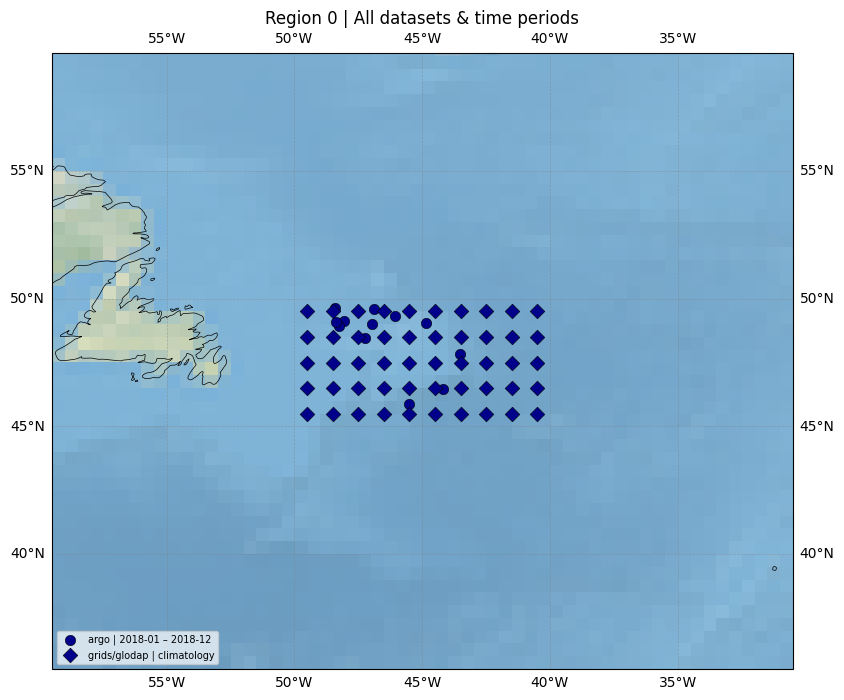

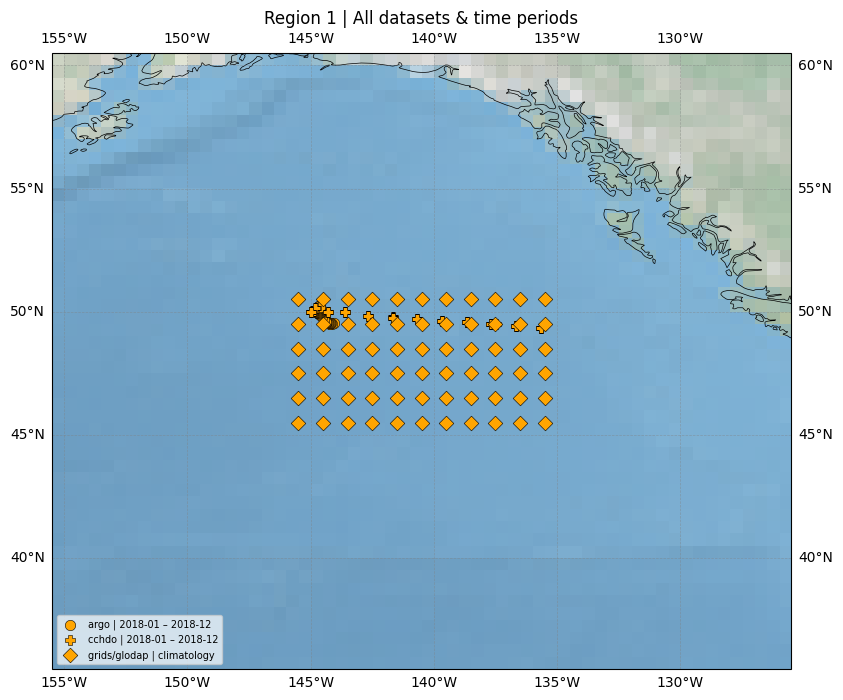

In [7]:
for region_idx in range(len(next(iter(insitu_raw.values())))):
    region_color = REGION_COLORS[region_idx % len(REGION_COLORS)]
    all_lons, all_lats, labels, colors, markers = [], [], [], [], []
    for ds in insitu_raw:
        for time_idx, time_list in enumerate(insitu_raw[ds][region_idx]):
            lons = [p.longitude for p in time_list]
            lats = [p.latitude  for p in time_list]
            if not lats or not lons:
                continue
            datestring = (f"{time_periods[time_idx]['startDate'][:7]} – "
                          f"{time_periods[time_idx]['endDate'][:7]}")
            all_lons.append(lons);  all_lats.append(lats)
            labels.append(f'{ds} | {datestring}')
            colors.append(region_color)
            markers.append(DATASET_MARKERS.get(ds, 'o'))
    for ds in glodap_profiles:
        for time_idx, time_list in enumerate(glodap_profiles[ds][region_idx]):
            lons = [p.longitude for p in time_list]
            lats = [p.latitude  for p in time_list]
            if not lats or not lons:
                continue
            all_lons.append(lons);  all_lats.append(lats)
            labels.append(f'{ds} | climatology')
            colors.append(region_color)
            markers.append(DATASET_MARKERS.get(ds, 'D'))
    plot_maps(all_lats, all_lons,
              title=f'Region {region_idx} | All datasets & time periods',
              labels=labels, colors=colors, markers=markers)

## Visualization — Part 1b: individual oxygen profiles

All individual profiles plotted together on a single axis. This shows the spread within each region before looking at the mean.

**Encoding:** color = region, marker = dataset, dotted = climatology.  
Depth axis limited to `DEPTH_YLIM` dbar (set in the configuration cell).

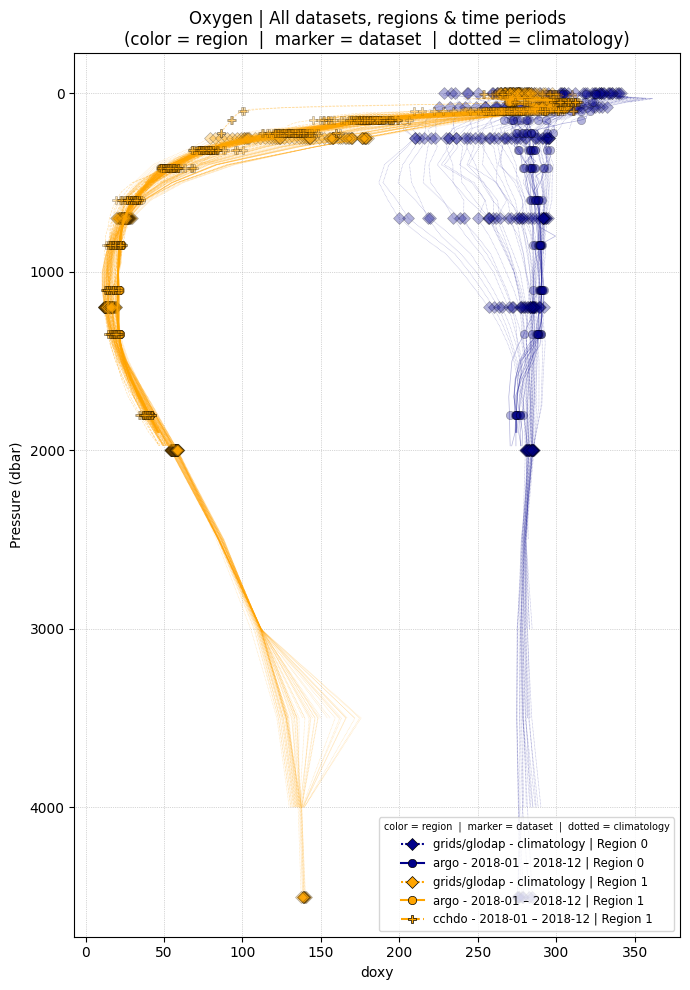

In [8]:
fig, ax = plt.subplots(figsize=(7, 10))
all_handles = []
for ri in range(len(regions)):
    region_color = REGION_COLORS[ri % len(REGION_COLORS)]

    # GLODAP climatology
    glodap_profiles_sel = {k: v[ri][0] for k, v in glodap_profiles.items()
                           if ri < len(v) and len(v[ri]) > 0}
    for ds, profiles in glodap_profiles_sel.items():
        handles = compare_profiles(
            {ds: profiles}, 'oxygen',
            dataset_colors=DATASET_COLORS,
            time_linestyles=TIME_LINESTYLES,
            depth_ylim=DEPTH_YLIM,
            region_label=f'Region {ri}',
            datestring='climatology',
            ax=ax,
            linestyle=DATASET_LINESTYLES.get(ds, (0, (1, 1))),
            marker=DATASET_MARKERS.get(ds, 'D'),
            markevery=5,
            markersize=REGION_MARKERSIZE,
            markeredgecolor=REGION_MARKEREDGECOLOR,
            markeredgewidth=REGION_MARKEREDGEWIDTH,
            color=region_color,
        )
        all_handles.extend(handles)

    # In-situ datasets
    for ti in range(len(time_periods)):
        datestring = f"{time_periods[ti]['startDate'][:7]} – {time_periods[ti]['endDate'][:7]}"
        insitu_interp_sel = {k: v[ri][ti] for k, v in insitu_interp.items()
                             if ri < len(v) and ti < len(v[ri])}
        for ds, profiles in insitu_interp_sel.items():
            handles = compare_profiles(
                {ds: profiles}, 'doxy',
                dataset_colors=DATASET_COLORS,
                time_linestyles=TIME_LINESTYLES,
                depth_ylim=DEPTH_YLIM,
                region_label=f'Region {ri}',
                datestring=datestring,
                ax=ax,
                linestyle=DATASET_LINESTYLES.get(ds, '-'),
                marker=DATASET_MARKERS.get(ds, 'o'),
                markevery=5,
                markersize=REGION_MARKERSIZE,
                markeredgecolor=REGION_MARKEREDGECOLOR,
                markeredgewidth=REGION_MARKEREDGEWIDTH,
                color=region_color,
            )
            all_handles.extend(handles)

legend_title = 'color = region  |  marker = dataset'
if len(time_periods) > 1:
    legend_title += '  |  linestyle = time period'
if glodap_profiles:
    legend_title += '  |  dotted = climatology'

seen = set()
unique_handles = [h for h in all_handles
                  if h.get_label() not in seen and not seen.add(h.get_label())]
ax.legend(
    handles=unique_handles,
    loc='best',
    fontsize='small',
    title=legend_title,
    title_fontsize='x-small'
)
ax.set_title(f"Oxygen | All datasets, regions & time periods\n({legend_title})")
plt.tight_layout()
plt.show()

## Visualization — Part 2a: mean profiles

One mean profile per dataset × region × time period, plotted together with a GLODAP climatological profile for reference.

**Encoding:** color = region, marker = dataset, linestyle = time period, dotted = climatology.  
Depth axis limited to `DEPTH_YLIM` dbar (set in the configuration cell).  
To add or remove a variable, edit the `VARMAP` dictionary at the top of this cell.

> **On averaging behaviour:** `average_profiles_dict` uses `np.nanmean`, so each pressure level is averaged over however many profiles have a valid value there. This means deeper levels may be based on fewer profiles than shallower ones. The advantage is that the mean profile extends to the full depth range of the data rather than being truncated at the shallowest profile's maximum depth. To use a strict (standard) mean instead (only including levels where all profiles have valid data), pass `use_nanmean=False` to `average_profiles_dict`.

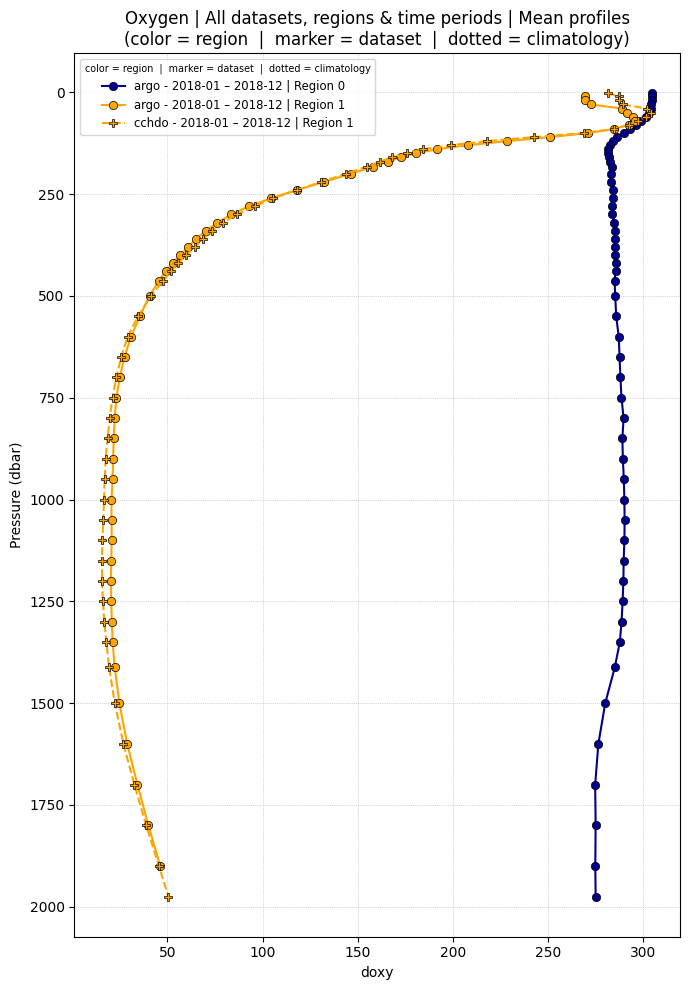

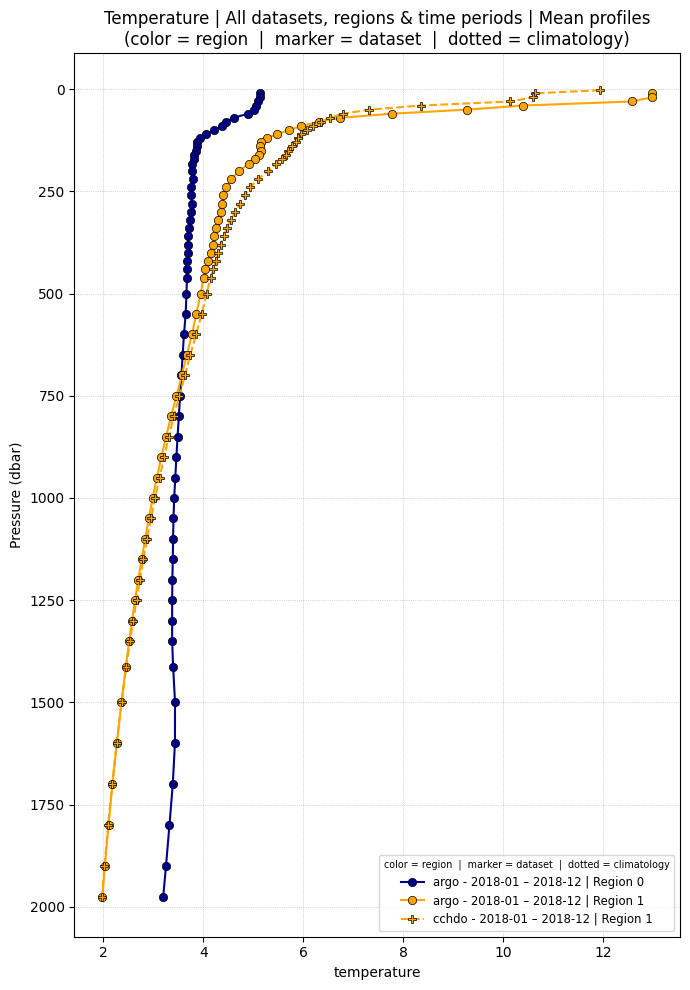

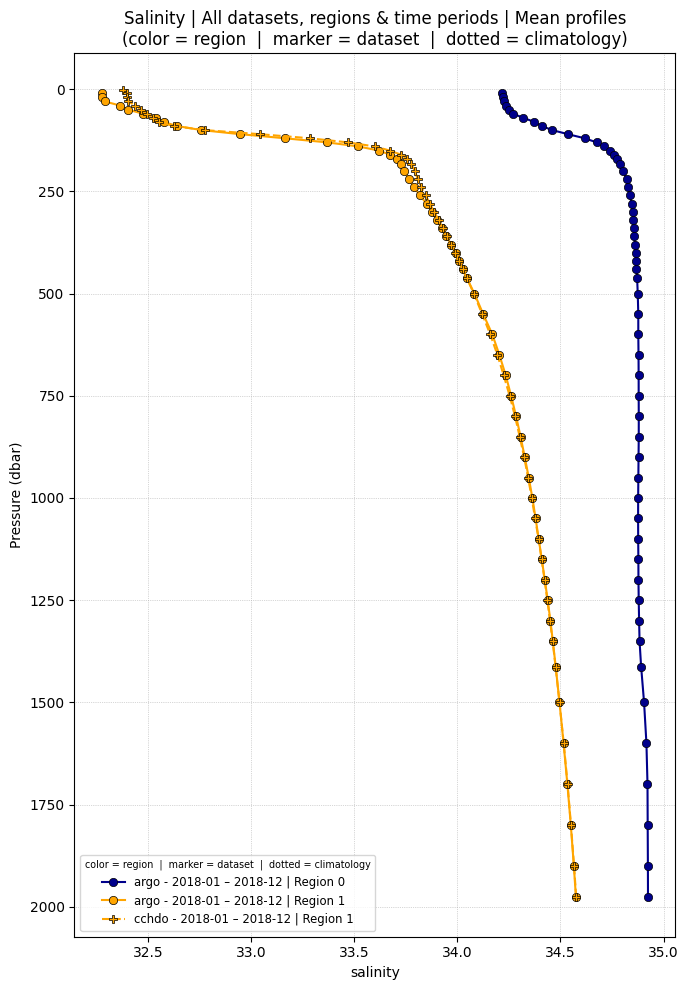

In [9]:
VARMAP = {
    'oxygen':      {'glodap': 'oxygen',      'insitu': 'doxy'},
    'temperature': {'glodap': 'temperature', 'insitu': 'temperature'},
    'salinity':    {'glodap': 'salinity',     'insitu': 'salinity'},
}
for varname, varmap in VARMAP.items():
    fig, ax = plt.subplots(figsize=(7, 10))
    all_handles = []
    for ri in range(len(regions)):
        region_color = REGION_COLORS[ri % len(REGION_COLORS)]

        # ── GLODAP: area-weighted mean ──────────────────────────────────
        ds_grid = glodap_raw['grids/glodap'][ri][0]
        glodap_var = varmap['glodap']
        if glodap_var in ds_grid:
            weights = np.cos(np.deg2rad(ds_grid.latitude))
            oxy_weighted = (
                ds_grid[glodap_var]
                .weighted(weights)
                .mean(dim=['latitude', 'longitude'])
                .mean(dim='timestamp')
            )
            glodap_handle, = ax.plot(
                oxy_weighted.values, glodap_levels,
                color=region_color,
                linewidth=2,
                linestyle=DATASET_LINESTYLES.get('grids/glodap', (0, (1, 1))),
                marker=DATASET_MARKERS.get('grids/glodap', 'D'),
                markevery=5,
                markersize=REGION_MARKERSIZE,
                markeredgecolor=REGION_MARKEREDGECOLOR,
                markeredgewidth=REGION_MARKEREDGEWIDTH,
                label=f"grids/glodap - climatology | Region {ri}"
            )
            all_handles.append(glodap_handle)

        # ── In-situ: average_profiles_dict → compare_profiles ─────────
        for ti in range(len(time_periods)):
            datestring = f"{time_periods[ti]['startDate'][:7]} – {time_periods[ti]['endDate'][:7]}"
            insitu_interp_sel = {k: v[ri][ti] for k, v in insitu_interp.items()
                                  if ri < len(v) and ti < len(v[ri])}
            insitu_mean = average_profiles_dict(insitu_interp_sel, use_nanmean=True)
            for ds, profiles in insitu_mean.items():
                handles = compare_profiles(
                    {ds: profiles}, varmap['insitu'],
                    dataset_colors=DATASET_COLORS,
                    time_linestyles=TIME_LINESTYLES,
                    depth_ylim=DEPTH_YLIM,
                    region_label=f'Region {ri}',
                    datestring=datestring,
                    mean_style=True,
                    ax=ax,
                    linestyle=DATASET_LINESTYLES.get(ds, '-'),
                    marker=DATASET_MARKERS.get(ds, 'o'),
                    markevery=1,
                    markersize=REGION_MARKERSIZE,
                    markeredgecolor=REGION_MARKEREDGECOLOR,
                    markeredgewidth=REGION_MARKEREDGEWIDTH,
                    color=region_color,
                )
                all_handles.extend(handles)

    legend_title = 'color = region  |  marker = dataset'
    if len(time_periods) > 1:
        legend_title += '  |  linestyle = time period'
    if glodap_profiles:
        legend_title += '  |  dotted = climatology'
    seen = set()
    unique_handles = [h for h in all_handles
                      if h.get_label() not in seen and not seen.add(h.get_label())]
    ax.legend(
        handles=unique_handles,
        loc='best',
        fontsize='small',
        title=legend_title,
        title_fontsize='x-small'
    )
    if DEPTH_YLIM is not None:
        ax.set_ylim(DEPTH_YLIM, 0)
    ax.set_title(f"{varname.capitalize()} | All datasets, regions & time periods | Mean profiles\n"
                 f"({legend_title})")
    plt.tight_layout()
    plt.show()

## Visualization — Part 2b: Gridded data (GLODAP)
GLODAP provides gridded fields on a regular latitude–longitude grid at discrete depth levels. The maps below show horizontal slices of oxygen at two depth levels, giving spatial context for the profiles above.

The color scale is unified across all panels so oxygen concentrations are directly comparable between regions and levels.

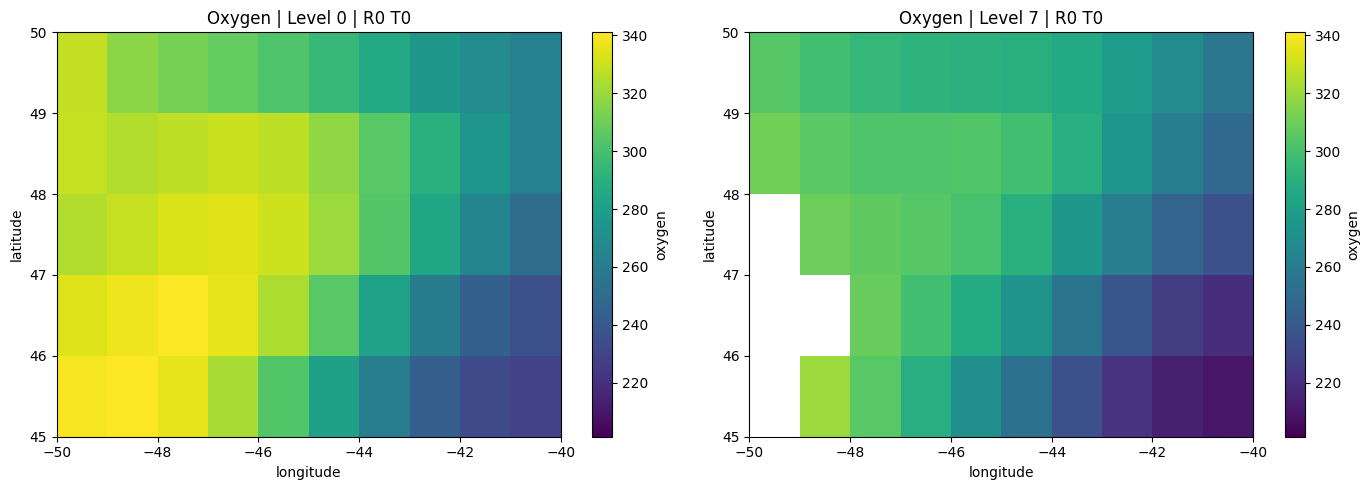

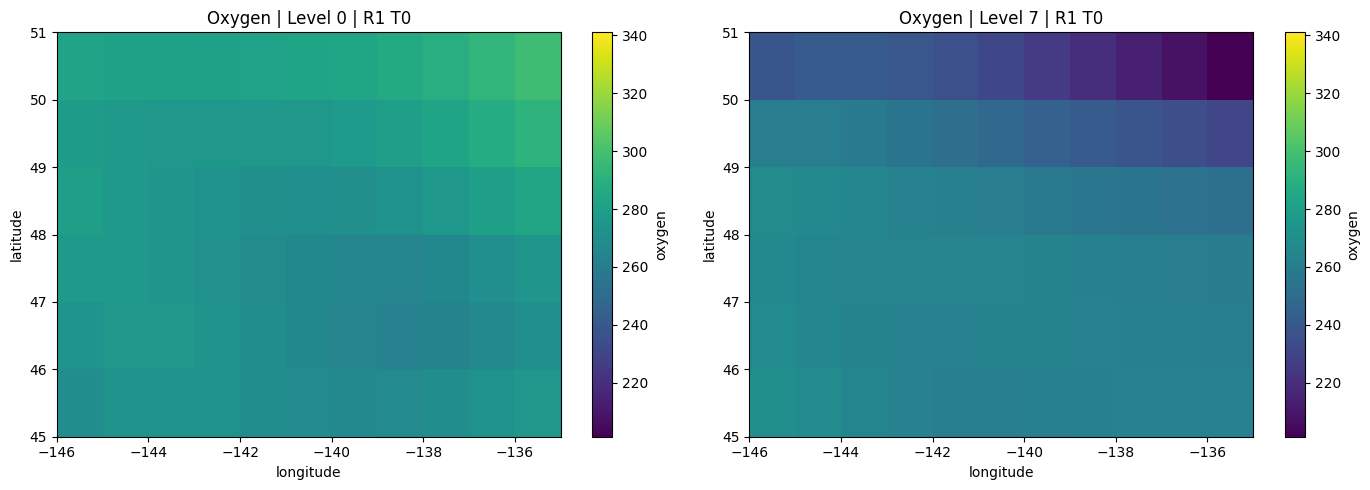

In [10]:
glodap_time = [{"startDate": "1000-01-01T00:00:00Z", "endDate": "1000-01-01T00:00:01Z"}]
glodap_raw  = traverse_query(regions, glodap_time, {"grids/glodap": "temperature,oxygen,salinity"}, avh.queryGrid, APIKEY, APIROOT)

all_data = [
    glodap_raw['grids/glodap'][i][j]["oxygen"].isel(timestamp=0, level=lv)
    for i in range(len(regions))
    for j in range(len(glodap_time))
    for lv in [0, 7]
]
vmin = min(d.min().item() for d in all_data)
vmax = max(d.max().item() for d in all_data)

for i in range(len(regions)):
    for j in range(len(glodap_time)):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, lv in zip(axes, [0, 7]):
            glodap_raw['grids/glodap'][i][j]["oxygen"].isel(timestamp=0, level=lv).plot(
                x='longitude', y='latitude', vmin=vmin, vmax=vmax, ax=ax
            )
            ax.set_title(f'Oxygen | Level {lv} | R{i} T{j}')
        fig.tight_layout()
        plt.show()
        plt.close()

# Question 1
## Using (all) the plots in “Visualization – Part 2” describe the differences in oxygen concentration between the two basins.
#### Please reply in the cell below.

# Part 3 — Platforms and WOCE repeat lines

This section allows you to zoom in on a specific **Argo platform** (a single float tracked over time) or a **GO-SHIP / WOCE repeat hydrographic line** (a ship transect repeated roughly every 10 years).

Use `query_mode` in the configuration cell below to select which source to explore:
- `"platform"` — track one or more Argo floats by WMO number
- `"woce"` — retrieve one or more WOCE/GO-SHIP repeat occupancies
- `["platform", "woce"]` — run both simultaneously

### About EasyOcean

The GO-SHIP Easy Ocean data product combines, reformats, and grids data from Conductivity-Temperature-Depth-Oxygen (CTDO) profilers collected on GO-SHIP repeat hydrographic sections, in order to facilitate their use by a wider audience ([Swift et al., 2022](https://doi.org/10.1038/s41597-022-01212-w)).

Section names for GO-SHIP Easy Ocean gridded sections and corresponding occupancy dates can be listed by uncommenting and running the code below.

In [11]:
# # ── EasyOcean: available sections and occupancy start dates ──────────────
# easyocean_meta = avh.query("easyocean/meta", {}, apikey=APIKEY, apiroot=APIROOT)
# print("EasyOcean sections")
# print("=" * 60)
# for m in sorted(easyocean_meta, key=lambda x: x['_id']):
#     dates = [o['time_boundaries'][0][:10] for o in m.get('occupancies', [])]
#     print(f"  {m['_id']:>20s}  occupancies: {dates}")


## Setup: platform / WOCE configuration

Fill in the blocks below for your chosen `query_mode`. Only the block(s) matching the active mode will be queried.

- **Platform block**: provide one or more Argo float WMO numbers in `target_platform`
- **WOCE block**: provide one or more WOCE line names in `target_woce`; set `target_woce_occupancy_index` to select which occupancy to use (`-1` = most recent)

In [12]:
query_mode = "woce"  # options: "platform", "woce", or ["platform", "woce"]

# PLATFORM configuration
collection_platform = {"argo": "temperature,salinity,doxy"}
target_platform     = [
    {"platform": "4903274"},
    {"platform": "4902599"}
]
time_periods_platform = [
    {"startDate": "2010-01-01T00:00:00Z", "endDate": "2023-01-01T00:00:00Z"}
]

# WOCE configuration
collection_woce = {
    "easyocean": "ctd_temperature,ctd_salinity,doxy",
}
target_woce = [
    {"woceline": "P16"},
    {"woceline": "A16-A23"}
]
# Index of the occupancy to use per line. -1 = most recent.
target_woce_occupancy_index = [-1, -1]

# Normalise query_mode to a list
_modes = [query_mode] if isinstance(query_mode, str) else list(query_mode)
print(f"Active mode: {_modes}")

Active mode: ['woce']


### Step 1 — Query profiles

For **platform** mode, profiles are queried directly by float ID and time range.  
For **WOCE** mode, a metadata pre-query is run first to determine the exact time boundaries of the selected occupancy, then the full profile query is issued.

In [13]:
active_raw         = {}
active_targets     = {}
active_time_periods = {}
active_collections = {}

if "platform" in _modes:
    print("Querying Argo platforms...")
    platform_raw = traverse_query(target_platform, time_periods_platform, collection_platform, avh.queryProfile, APIKEY, APIROOT)
    active_raw["platform"]          = platform_raw
    active_targets["platform"]      = target_platform
    active_time_periods["platform"] = time_periods_platform
    active_collections["platform"]  = collection_platform

if "woce" in _modes:
    print("Querying WOCE line metadata...")
    # Always use easyocean/meta for occupancy time boundaries,
    # since cchdo/meta doesn't have the 'occupancies' field.
    woce_raw_metadata = traverse_query(
        target_woce, [{}],
        {"easyocean/meta": list(collection_woce.values())[0]},
        avh.query, APIKEY, APIROOT
    )
    _meta_key = list(woce_raw_metadata.keys())[0]
    time_periods_woce = [
        {
            "startDate": i_val[0][0]['occupancies'][target_woce_occupancy_index[i]]['time_boundaries'][0],
            "endDate":   i_val[0][0]['occupancies'][target_woce_occupancy_index[i]]['time_boundaries'][1]
        }
        for i, i_val in enumerate(woce_raw_metadata[_meta_key])
    ]
    print(f"WOCE time periods: {time_periods_woce}")
    print("Querying WOCE profiles...")
    # Profile query uses all collections (easyocean, cchdo, etc.)
    woce_raw = traverse_query(target_woce, time_periods_woce, collection_woce, avh.queryProfile, APIKEY, APIROOT)
    active_raw["woce"]          = woce_raw
    active_targets["woce"]      = target_woce
    active_time_periods["woce"] = time_periods_woce
    active_collections["woce"]  = collection_woce

print("Done.")

Querying WOCE line metadata...
WOCE time periods: [{'startDate': '2014-03-31T00:00:00.000Z', 'endDate': '2015-06-18T00:00:00.000Z'}, {'startDate': '2013-08-03T00:00:00.000Z', 'endDate': '2014-01-29T00:00:00.000Z'}]
Querying WOCE profiles...
Done.


### Step 2 — Compute derived variables

The following variables are computed for each profile using the [GSW Oceanographic Toolbox](https://www.teos-10.org/):

- `absolute_salinity`  SA — salinity on the TEOS-10 absolute scale (g/kg) 
- `potential_temperature`  θ — temperature a water parcel would have if moved adiabatically to the surface 
- `conservative_temperature`  Θ — more accurate heat content proxy (TEOS-10) 
- `density`  In-situ seawater density (kg/m³) 
- `potential_density`  σ₀ — density a water parcel would have if moved adiabatically to the surface without salt exchange; used for MLD calculation 
- `MLD`  Mixed layer depth from a potential density threshold of 0.03 kg/m³ 
- `apparent_oxygen_utilization`  AOU = O₂_sat − O₂_obs; proxy for biological oxygen consumption (requires `doxy`) 

In [14]:
for mode, raw in active_raw.items():
    for ds, route_results in raw.items():
        if ds not in salinity_key or ds not in temperature_key:
            continue
        for region_results in route_results:
            for time_results in region_results:
                for p in time_results:
                    try:
                        p.setvar('absolute_salinity',
                            gsw.conversions.SA_from_SP(
                                p.getvar(salinity_key[ds]), p.getvar('pressure'),
                                p.longitude, p.latitude))
                        p.setvar('potential_temperature',
                            gsw.conversions.pt0_from_t(
                                p.getvar('absolute_salinity'), p.getvar(temperature_key[ds]),
                                p.getvar('pressure')))
                        p.setvar('conservative_temperature',
                            gsw.conversions.CT_from_t(
                                p.getvar('absolute_salinity'), p.getvar(temperature_key[ds]),
                                p.getvar('pressure')))
                        p.setvar('density',
                            gsw.rho(
                                p.getvar('absolute_salinity'), p.getvar('conservative_temperature'),
                                p.getvar('pressure')))
                        p.setvar('potential_density',
                            gsw.sigma0(
                                p.getvar('absolute_salinity'), p.getvar('conservative_temperature')
                            ) + 1000)
                        p.setvar('MLD',
                            [ava.MLD_estimate(p.getvar('pressure'), p.getvar('potential_density'), 0.03)[0]])
                        if 'doxy' in p.vars:
                            p.setvar('apparent_oxygen_utilization',
                                ava.AOU_estimate(
                                    p.getvar('absolute_salinity'), p.getvar('conservative_temperature'),
                                    p.getvar('pressure'), p.longitude, p.latitude, p.getvar('doxy'))[0])
                    except Exception as e:
                        print(f"  Skipping profile {p.rawdata.get('_id','?')} in {ds}: {e}")

### Step 3 — Interpolate onto common pressure levels

In [ ]:
# MLD is a scalar (one value per profile, not per level) and must be
# removed before interpolation and restored on the interpolated profile.
active_interp = {}
for mode, raw in active_raw.items():
    active_interp[mode] = {}
    for route, route_results in raw.items():
        active_interp[mode][route] = []
        for region_results in route_results:
            region_interp = []
            for time_results in region_results:
                time_interp = []
                for p in time_results:
                    mld_val = p.getvar('MLD') if 'MLD' in p.vars else None
                    if mld_val is not None:
                        p.delvar('MLD')
                    p_interp = ava.interpolate_all(p, interpolation_levels)
                    if mld_val is not None:
                        p_interp.setvar('MLD', mld_val)
                    time_interp.append(p_interp)
                region_interp.append(time_interp)
            active_interp[mode][route].append(region_interp)

## Visualization — Part 3a: profile locations

All sections plotted on a shared map, colored by section name. Use this to locate the WOCE lines geographically.

In [ ]:
for mode, profiles_dict in active_interp.items():
    targets      = active_targets[mode]
    time_periods = active_time_periods[mode]
    label_key    = 'platform' if mode == 'platform' else 'woceline'

    for ds, regions_list in profiles_dict.items():
        # ── Shared map: all sections on one figure ────────────────────────
        fig, ax = plt.subplots(figsize=(12, 8),
                               subplot_kw={'projection': ccrs.PlateCarree()})
        ax.stock_img()
        ax.coastlines(resolution='50m', color='black', linewidth=0.5)

        for region_idx, region_list in enumerate(regions_list):
            for time_idx, time_list in enumerate(region_list):
                if not time_list:
                    continue
                lons = [p.longitude for p in time_list]
                lats = [p.latitude  for p in time_list]
                tp   = time_periods[time_idx]
                datestring   = f"{tp['startDate'][:7]} – {tp['endDate'][:7]}"
                region_label = targets[region_idx][label_key]
                section_color = SECTION_COLORS.get(region_label, 'black')

                plot_maps(lats, lons,
                          title=f'{ds} | WOCE sections',
                          fig_settings={'ax': ax, 'show_plot': False},
                          colors=[section_color],
                          labels=[f'{region_label} | {datestring} | N={len(time_list)}'])
        ax.set_global()
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = True
        ax.legend(loc='lower left', fontsize=7, framealpha=0.7)
        plt.tight_layout()
        plt.show()


## Visualization — Part 3b: individual profiles *(optional)*

The cell below plots all individual profiles per region and time period. Commented out by default — it can be slow for large WOCE sections with many stations.

Uncomment and run if you want to inspect the spread before looking at the mean.

In [ ]:
# for mode, profiles_dict in active_interp.items():
#     targets      = active_targets[mode]
#     time_periods = active_time_periods[mode]
#     label_key    = 'platform' if mode == 'platform' else 'woceline'
#
#     for ri in range(len(targets)):
#         for ti in range(len(time_periods)):
#             profiles_sel = {k: v[ri][ti] for k, v in profiles_dict.items()}
#             datestring   = f"{time_periods[ti]['startDate'][:4]}-{time_periods[ti]['endDate'][:4]}"
#             compare_profiles(profiles_sel, 'temperature',
#                              varname_lookup=temperature_key,
#                              region_label=targets[ri][label_key],
#                              datestring=datestring)  

## Visualization — Part 3c: mean vertical profiles

Mean profiles of temperature, salinity, and oxygen for each platform/WOCE line and time period, overlaid on a single axis per variable.

**Encoding:** color = section, marker = section, linestyle = time period.  
Depth axis limited to `DEPTH_YLIM` dbar (set in the configuration cell).

In [ ]:
varname_lookups = {
    'temperature': temperature_key,
    'salinity':    salinity_key,
    'doxy':        {ds: 'doxy' for ds in {**temperature_key, **salinity_key}},
}

for mode, profiles_dict in active_interp.items():
    targets      = active_targets[mode]
    time_periods = active_time_periods[mode]
    label_key    = 'platform' if mode == 'platform' else 'woceline'

    for var, lookup in varname_lookups.items():
        fig, ax = plt.subplots(figsize=(6, 8))
        all_handles = []

        for ti in range(len(time_periods)):
            tp         = time_periods[ti]
            datestring = f"{tp['startDate'][:10]}-{tp['endDate'][:10]}"
            linestyle  = TIME_LINESTYLES[ti % len(TIME_LINESTYLES)]

            for ri in range(len(targets)):
                region_label  = targets[ri][label_key]
                region_marker = REGION_MARKERS[ri % len(REGION_MARKERS)]
                section_color = SECTION_COLORS.get(region_label, 'black')
                profiles_sel  = {k: v[ri][ti] for k, v in profiles_dict.items()
                                  if ri < len(v) and ti < len(v[ri])}
                profiles_mean = average_profiles_dict(profiles_sel, use_nanmean=True)
                handles = compare_profiles(
                    profiles_mean, var,
                    dataset_colors=DATASET_COLORS,
                    time_linestyles=TIME_LINESTYLES,
                    depth_ylim=DEPTH_YLIM,
                    varname_lookup=lookup,
                    region_label=region_label,
                    datestring=datestring,
                    mean_style=True,
                    ax=ax,
                    linestyle=linestyle,
                    marker=region_marker,
                    markevery=1,
                    markersize=REGION_MARKERSIZE,
                    markeredgecolor=REGION_MARKEREDGECOLOR,
                    markeredgewidth=REGION_MARKEREDGEWIDTH,
                    color=section_color,
                )
                all_handles.extend(handles)

        seen = set()
        unique_handles = [h for h in all_handles
                          if h.get_label() not in seen and not seen.add(h.get_label())]
        ax.legend(
            handles=unique_handles,
            loc='best',
            fontsize='small',
            title='color = section  |  marker = section  |  linestyle = time period',
            title_fontsize='x-small'
        )
        ax.set_title(f"{mode.upper()} | Mean {var} | All sections & periods\n"
                     f"(color = section, linestyle = time period)")
        plt.tight_layout()
        plt.show()

## Visualization — Part 3d: latitude–depth sections

Each variable is shown as a color-filled latitude–depth section (`pcolormesh`), with the mixed layer depth (MLD) overlaid as a white dashed line when `overlay_mld = True`.

These sections reveal how water mass properties evolve along the cruise track or float trajectory, and where the mixed layer separates the surface from the ocean interior.

Set `overlay_mld = False` to hide the MLD overlay.  
Set `side_by_side = True` to plot all regions for the same variable in a single figure (one column per region); set to `False` for one figure per region.  
Depth range is controlled by `DEPTH_YLIM` in the configuration cell.

In [ ]:
overlay_mld  = True   # set to False to disable MLD overlay
side_by_side = True   # set to False to revert to one plot per region

fnt_sz = 14

for mode, profiles_dict in active_interp.items():
    for dataset_name, regions_list in profiles_dict.items():

        # ── Collect all (region, time) combos that have data ─────────────────
        region_data = []
        for region_idx, time_list in enumerate(regions_list):
            for time_idx, profiles in enumerate(time_list):
                if not profiles:
                    continue

                tp         = active_time_periods[mode][time_idx]
                datestring = f"{tp['startDate'][:10]}—{tp['endDate'][:10]}"
                profiles_sorted = sorted(profiles, key=lambda p: p.latitude)
                latitudes       = [p.latitude for p in profiles_sorted]

                if mode == "woce":
                    raw_id = profiles_sorted[0].rawdata.get('_id', '')
                    if '_date_' in raw_id:
                        section_id = raw_id.split('_date_')[0]
                    elif '_sta_' in raw_id:
                        section_id = raw_id.split('_sta_')[0]
                    else:
                        section_id = raw_id[:20]
                else:
                    section_id = active_targets[mode][region_idx].get('platform', f'region_{region_idx}')

                pressure_levels = numpy.array(profiles_sorted[0].getvar('pressure'), dtype=float)
                var_names       = [v for v in profiles_sorted[0].vars.keys() if v != 'pressure']
                mld_var         = next((v for v in var_names if 'MLD' in v), None)
                mld_vals        = [p.getvar(mld_var)[0] for p in profiles_sorted] if mld_var else None

                region_data.append({
                    'section_id'     : section_id,
                    'datestring'     : datestring,
                    'profiles_sorted': profiles_sorted,
                    'latitudes'      : latitudes,
                    'pressure_levels': pressure_levels,
                    'var_names'      : var_names,
                    'mld_var'        : mld_var,
                    'mld_vals'       : mld_vals,
                })

        if not region_data:
            continue

        # ── Union of variable names across all regions ────────────────────────
        all_var_names = []
        for rd in region_data:
            for v in rd['var_names']:
                if v not in all_var_names:
                    all_var_names.append(v)

        # ── One figure per variable ───────────────────────────────────────────
        for var_name in all_var_names:

            valid_regions = [rd for rd in region_data if var_name in rd['var_names']]
            if not valid_regions:
                continue

            n_cols = len(valid_regions) if side_by_side else 1

            if side_by_side:
                fig, axes = plt.subplots(1, n_cols, figsize=(12 * n_cols, 6))
                if n_cols == 1:
                    axes = [axes]

            for col_idx, rd in enumerate(valid_regions):
                ax = axes[col_idx] if side_by_side else plt.subplots(figsize=(12, 6))[1]

                latitudes       = rd['latitudes']
                pressure_levels = rd['pressure_levels']
                profiles_sorted = rd['profiles_sorted']
                mld_vals        = rd['mld_vals']

                if 'MLD' in var_name:
                    ax.plot(latitudes, mld_vals)
                    ax.set_ylabel('Mixed Layer Depth (dbar)', fontsize=fnt_sz)
                    ax.set_xlabel('Latitude', fontsize=fnt_sz)
                    ax.tick_params(axis='x', labelsize=fnt_sz)
                    ax.tick_params(axis='y', labelsize=fnt_sz)
                else:
                    section = numpy.array([p.getvar(var_name) for p in profiles_sorted]).T
                    mesh    = ax.pcolormesh(latitudes, pressure_levels, section,
                                            shading='auto', cmap='viridis')
                    cb = plt.colorbar(mesh, ax=ax, label=var_name)
                    cb.ax.tick_params(labelsize=fnt_sz)
                    cb.set_label(cb.ax.get_ylabel(), size=fnt_sz)
                    ax.set_xlabel('Latitude', fontsize=fnt_sz)
                    ax.set_ylabel('Pressure (dbar)', fontsize=fnt_sz)
                    ax.tick_params(axis='x', labelsize=fnt_sz)
                    ax.tick_params(axis='y', labelsize=fnt_sz)
                    if overlay_mld and mld_vals is not None:
                        ax.plot(latitudes, mld_vals,
                                color='white', linewidth=1.5,
                                linestyle='--', label=rd['mld_var'])
                        ax.legend(loc='lower right')
                    if DEPTH_YLIM is not None:
                        ax.set_ylim(DEPTH_YLIM, 0)
                    else:
                        ax.invert_yaxis()

                ax.set_title(f"{dataset_name} | {rd['section_id']} | {var_name} | {rd['datestring']}", fontsize=fnt_sz)

                if not side_by_side:
                    plt.tight_layout()
                    plt.show()

            if side_by_side:
                plt.tight_layout()
                plt.show()

# Question 2: 
## Using (all) the plots in “Visualization – Part 3d” describe the differences in oxygen concentration between the two basins.
#### Please reply in the cell below.